# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [1]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [2]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

### Understanding the structure of the data

In [3]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
# Write your code here to read the data
df = pd.read_csv('foodhub_order.csv')

In [5]:
# Write your code here to view the first 5 rows
print("The first 5 rows of the dataset are: ")
df.head()

The first 5 rows of the dataset are: 


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [6]:
# Write your code here
rows, cols = df.shape #assigns columns and rows to their respective var names
print(f"The dataset features {rows} rows and {cols} columns present.")

The dataset features 1898 rows and 9 columns present.


#### Observations:
This dataset contains a substantial amount of data with sufficient information for further analysis and observation with many records and a multitude of variables to explore.

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [7]:
# Write your code here
print("The different datatypes that can be found in the dataset are:")
df.info() #using info like the hint says

The different datatypes that can be found in the dataset are:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
The datatypes consist of integers, floats, and objects, representing a balanced dataset suitable for statistical analysis and visualization. No missing values are presenty.

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [8]:
# Write your code here
miss_vals = df.isnull().sum() #sums up missing values per column name
print("Here are the number of missing values per column in the dataset: ")
miss_vals

Here are the number of missing values per column in the dataset: 


order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64

#### Observations:
No missing values exist in any column in the dataset meaning no cleaning will be required and nothing will condemn the data or any plots/analysis conducted later on.

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [9]:
# Write your code here
print("The statistical summary of the data is as follows:")
print(df.describe)#for stat summary

min = df["food_preparation_time"].min()
avg = df["food_preparation_time"].mean()
max = df["food_preparation_time"].max()
avg = round(avg,2)



print("\n The minimum time for food to be perpared once an order is placed is", min)
print("\n The average time for food to be perpared once an order is placed is", avg)
print("\n The maximum time for food to be perpared once an order is placed is", max)

The statistical summary of the data is as follows:
<bound method NDFrame.describe of       order_id  customer_id                        restaurant_name  \
0      1477147       337525                                Hangawi   
1      1477685       358141              Blue Ribbon Sushi Izakaya   
2      1477070        66393                            Cafe Habana   
3      1477334       106968              Blue Ribbon Fried Chicken   
4      1478249        76942                       Dirty Bird to Go   
...        ...          ...                                    ...   
1893   1476701       292602  Chipotle Mexican Grill $1.99 Delivery   
1894   1477421       397537                              The Smile   
1895   1477819        35309                      Blue Ribbon Sushi   
1896   1477513        64151                      Jack's Wife Freda   
1897   1478056       120353                      Blue Ribbon Sushi   

       cuisine_type  cost_of_the_order day_of_the_week     rating  \
0    

#### Observations:
Based on the statistical summary, the minimum food preparation time is 20 minutes, the maximum is 35 minutes, and the average is approximately 27.37 minutes. This indicates that most orders take around half an hour to prepare, showing consistent preparation times across the dataset with limited variability.

### **Question 5:** How many orders are not rated? [1 mark]

In [10]:
# Write the code here
notRated = sum(df['rating'] == 'Not given') #finds all the not givens under rating
print("The number of orders that are not rated is", notRated)

The number of orders that are not rated is 736


#### Observations:
736 is nearly 40% of all records meaning that a fairly large portion of the orders placed were not rated which may impact certain analyses conducted later on based around ratings.

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

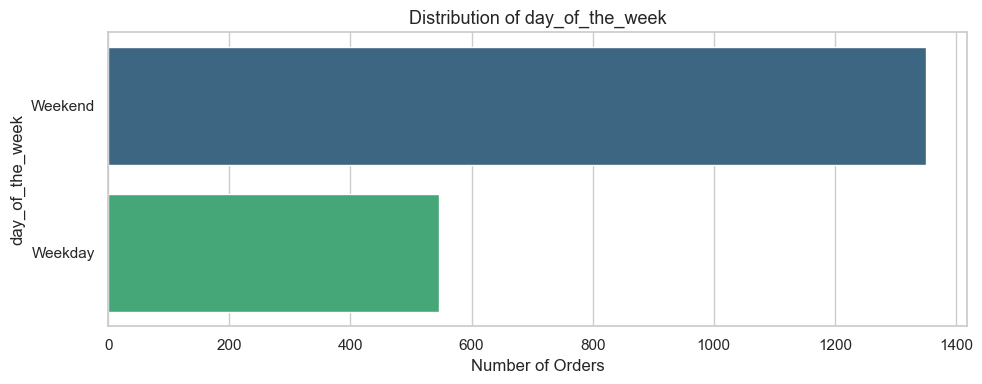

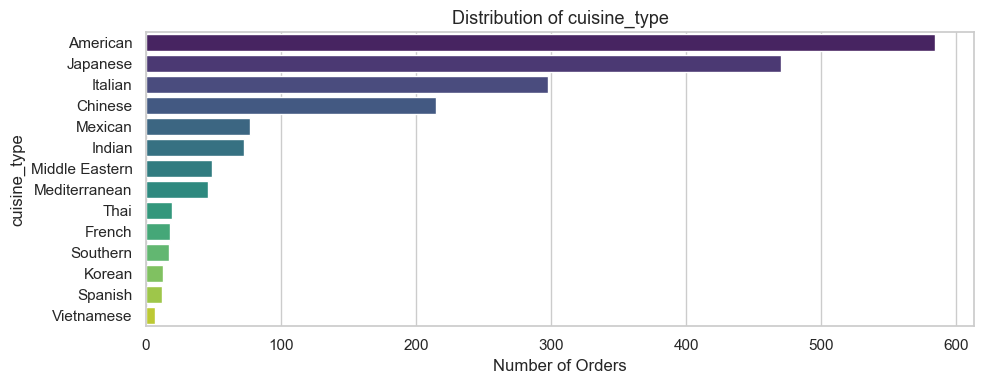

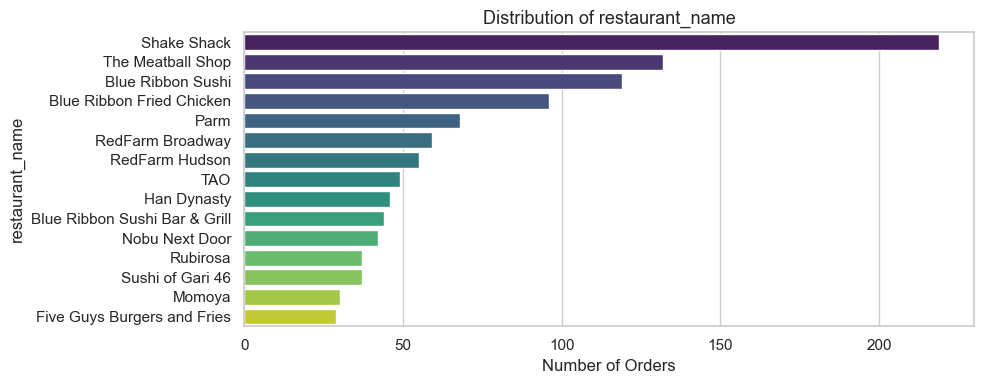

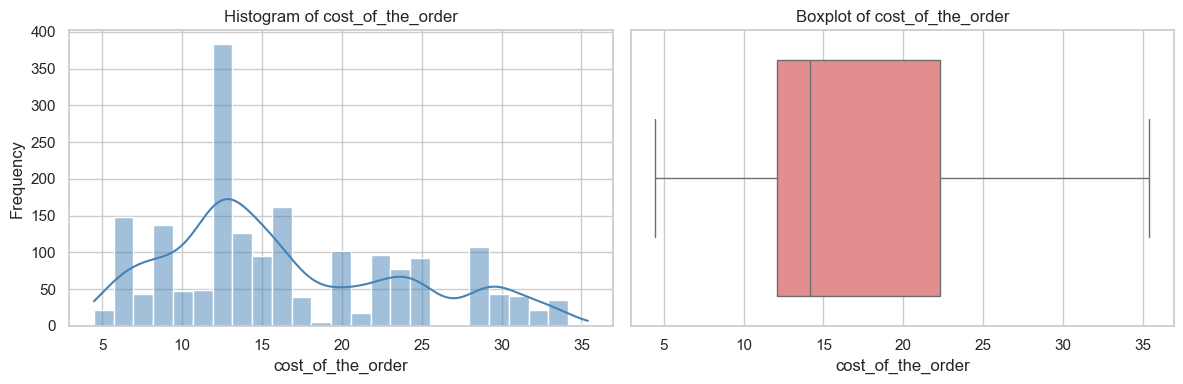

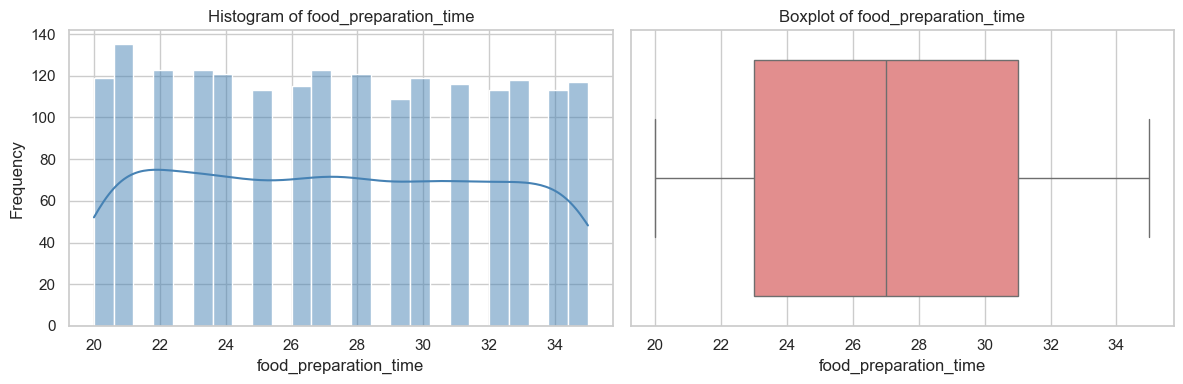

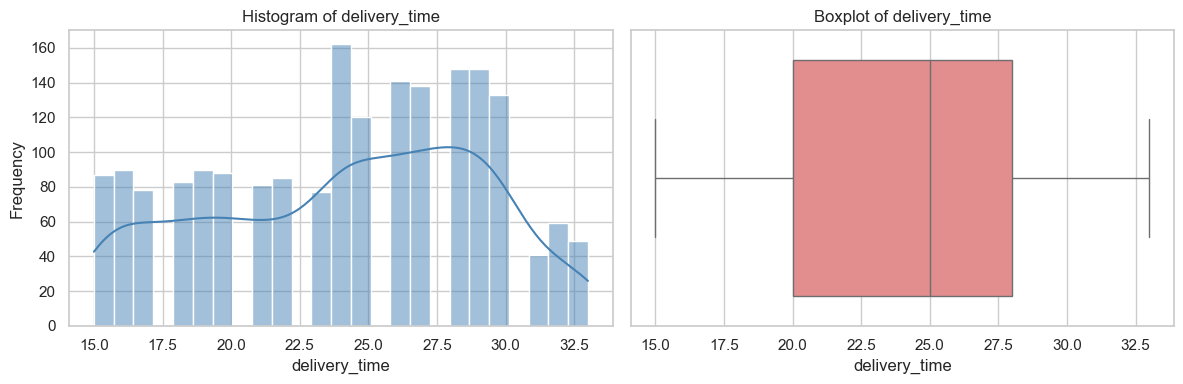

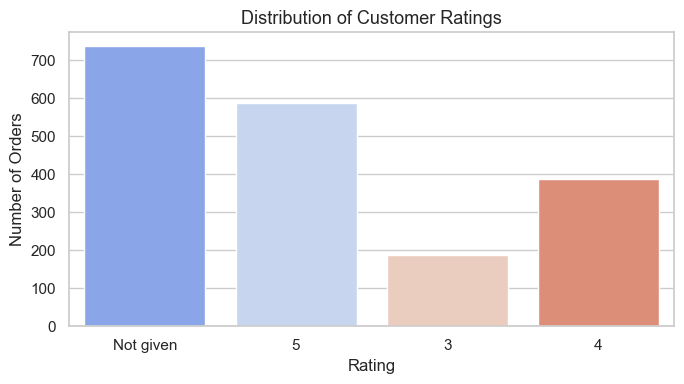

,Unique_Counts
order_id,1898
customer_id,1200


In [11]:
# Write the code here
warnings.filterwarnings("ignore")
sns.set(style="whitegrid", palette="muted") #grid for multiple plots

#seggregated variables based on assistance from Glaide
categorical_vars = ['day_of_the_week', 'cuisine_type', 'restaurant_name']
numerical_vars = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']
unique_counts = df[['order_id', 'customer_id']].nunique().to_frame('Unique_Counts')

#categorical variables will be charted in a barchart
for col in categorical_vars:
    plt.figure(figsize=(10, 4))
    order = df[col].value_counts().index[:15]  # top 15 for clarity
    sns.countplot(data=df, y=col, order=order, palette='viridis')
    plt.title(f"Distribution of {col}", fontsize=13)
    plt.xlabel("Number of Orders")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

#numerical variables will be charted by a histogram for distributions of continous data and a boxplot for
#outlier observations and spread of data
for col in numerical_vars:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    #Histogram
    sns.histplot(df[col], bins=25, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title(f"Histogram of {col}", fontsize=12)
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequency")

    #Boxplot
    sns.boxplot(x=df[col], ax=axes[1], color='lightcoral')
    axes[1].set_title(f"Boxplot of {col}", fontsize=12)
    axes[1].set_xlabel(col)
    plt.tight_layout()
    plt.show()

#Rating variable will be charted as a bar chart
plt.figure(figsize=(7, 4))
sns.countplot(x='rating', data=df, palette='coolwarm')
plt.title("Distribution of Customer Ratings", fontsize=13)
plt.xlabel("Rating")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

#"Unique counts" like order id and customer id won't be plotted as there's no pattern
display(unique_counts)

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [12]:
# Write the code here
print("The following restaurants recieve the most orders according to the data:\n")
df['restaurant_name'].value_counts().nlargest(5) #5 most frequently mentioned resteraunts in df

The following restaurants recieve the most orders according to the data:



Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: restaurant_name, dtype: int64

#### Observations:
Shake Shack was the most frequently ordered by quite a wide margin. The Meatball Shop and Blue Ribbon Sushi followed shortly after. Blue Ribbon Sushi and Blue Ribbon Fried Chicken are considered seperate resteraunts despite them still being under the same "Blue Ribbon" title. After Blue Ribbon Fried Chicken, there appears to be another great drop off in orders.

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [13]:
# Write the code here
weekends_df = df[df["day_of_the_week"] == "Weekend"] #filter to show only weekend orders
print("The following restaurants recieve the most orders on the weekends according to the data:\n")
weekends_df['restaurant_name'].value_counts().nlargest(5) #5 most frequently mentioned resteraunts in df


The following restaurants recieve the most orders on the weekends according to the data:



Shake Shack                  145
The Meatball Shop             95
Blue Ribbon Sushi             85
Blue Ribbon Fried Chicken     74
RedFarm Broadway              44
Name: restaurant_name, dtype: int64

#### Observations:
The top 4 remained the same implying that popularity is not dependent on the day of the week and is more consistent acorss the week. It seems that the weekend seems to be more popular than the weekday in terms of oders, seemingly >50% of total orders being on the weekend.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [14]:
# Write the code here
orders_all = df.shape[0] #total orders
orders_20 = df[df["cost_of_the_order"]>20].shape[0] #orders over 20 bucks
orders_perc = round(100*orders_20/orders_all,2) #calculates percent
print("The percentage of orders costing more than 20 dollars is ~", orders_perc,"%")

The percentage of orders costing more than 20 dollars is ~ 29.24 %


#### Observations:
The percentage of orders costing more than 20 dolalrs being less than 30% implies that most of the orders being made are probably cheaper fast food than from mainstrean restaurants.

### **Question 10**: What is the mean order delivery time? [1 mark]

In [15]:
# Write the code here
#calculates and prints mean order deliv time across orders
print("The mean order delivery time is ", round(df["delivery_time"].mean(),2),"minutes")

The mean order delivery time is  24.16 minutes


#### Observations:
The mean order delivery time is 24.16 minutes, indicating that deliveries are handled efficiently within a reasonable time frame.

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [16]:
# Write the code here
top3_customers = (
    df.groupby('customer_id')['order_id'] #finds customer and order number
    .count()
    .sort_values(ascending=False)
    .head(3) #displays top 3
    .reset_index() #doesnt enforce sorting
)

print("20% discount vouchers and 3 most frequent customers are:")
display(top3_customers)

20% discount vouchers and 3 most frequent customers are:


,customer_id,order_id
0,52832,13
1,47440,10
2,83287,9


#### Observations:
The top three most frequent customers are those with customer IDs 52832, 47440, and 83287, placing 13, 10, and 9 orders, respectively.

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


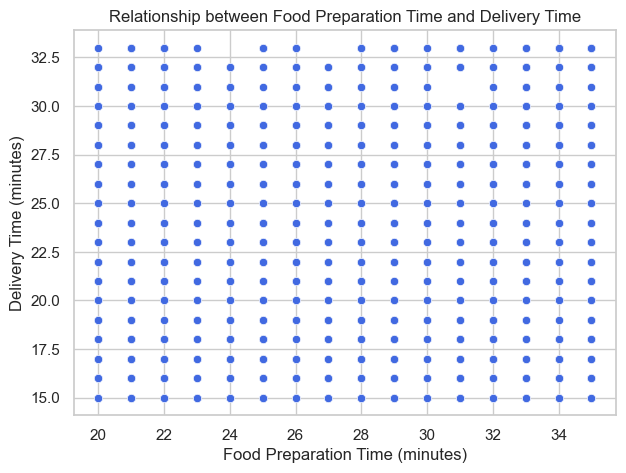

The objective with the above plot is to show if bigger orders take more time to deliver.



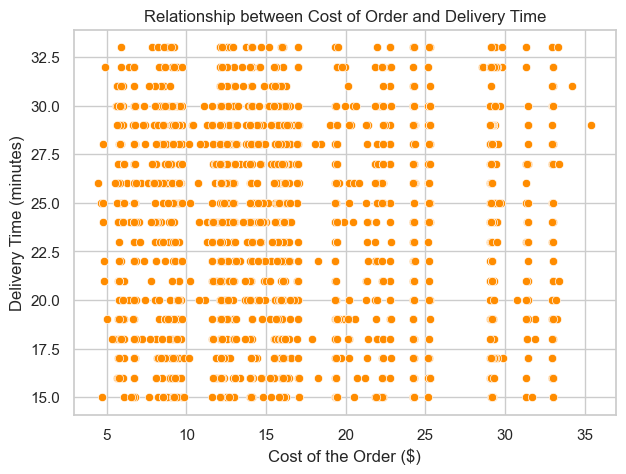

The objective with the above plot is to show if more expensive orders are delivered faster.



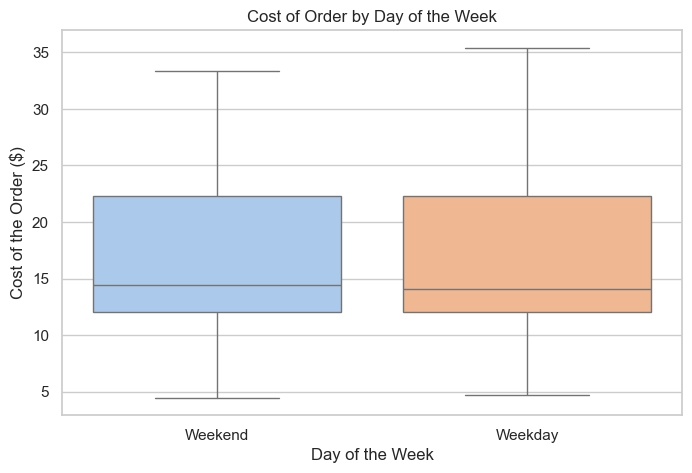

The objective with the above plot is to see if ordering food over the weekend is cheaper or more expensive.



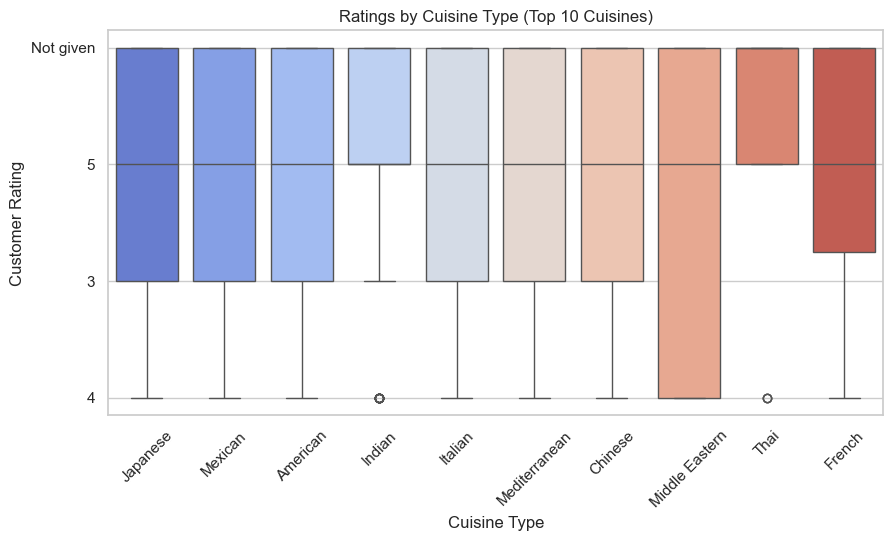

The objective with the above plot is to see if there are more favorable cuisines for delivery.



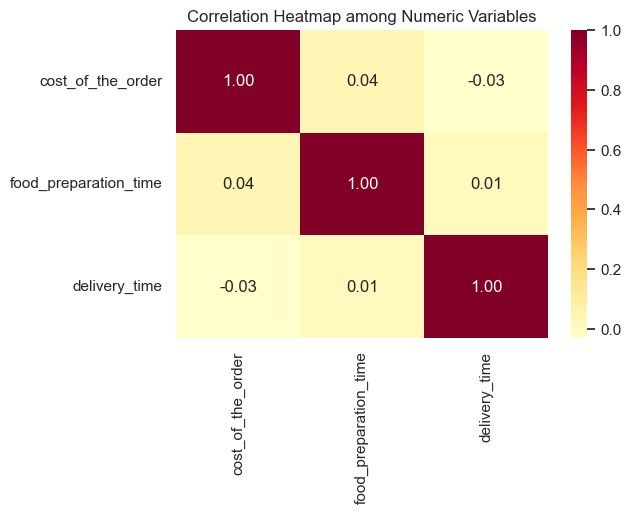

The objective with the above plot is to correlate all the numerical values in the data.


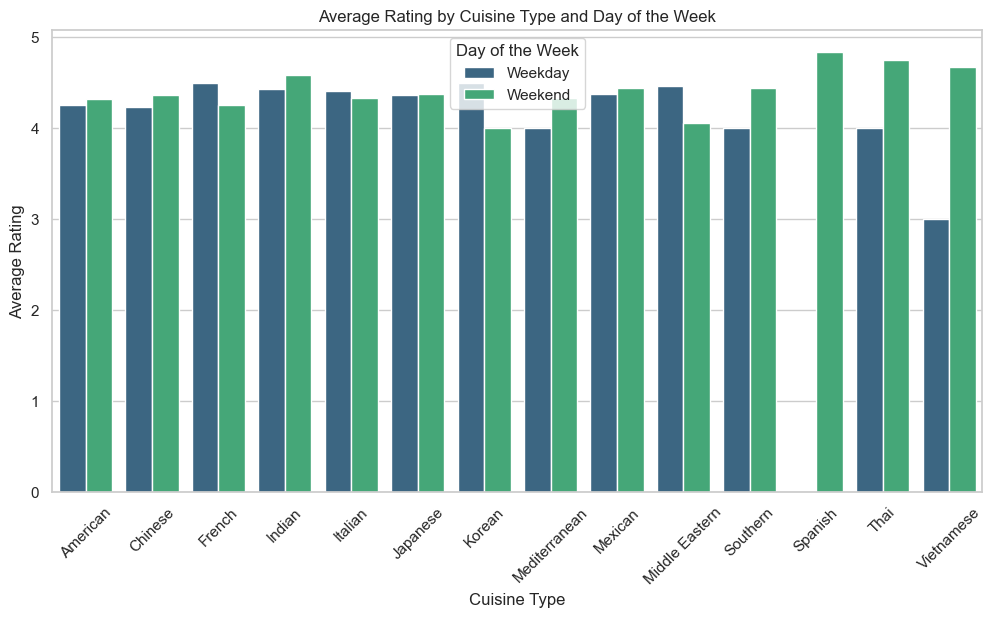

The objective with the above plot was to be multivariate in showing how different cuisines can maybe be better or worse depnding on if they're ordered on a weekday or weekend.



In [17]:
warnings.filterwarnings("ignore")

#Scatter plot to show food prep vs delivery time
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='food_preparation_time', y='delivery_time', color='royalblue')
plt.title("Relationship between Food Preparation Time and Delivery Time")
plt.xlabel("Food Preparation Time (minutes)")
plt.ylabel("Delivery Time (minutes)")
plt.show()

print("The objective with the above plot is to show if bigger orders take more time to deliver.\n")

#Scatterplot to show order cost vs delivery time
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='cost_of_the_order', y='delivery_time', color='darkorange')
plt.title("Relationship between Cost of Order and Delivery Time")
plt.xlabel("Cost of the Order ($)")
plt.ylabel("Delivery Time (minutes)")
plt.show()
print("The objective with the above plot is to show if more expensive orders are delivered faster.\n")


#Boxplot to show order cost vs day of week
plt.figure(figsize=(8, 5))
sns.boxplot(x='day_of_the_week', y='cost_of_the_order', data=df, palette='pastel')
plt.title("Cost of Order by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Cost of the Order ($)")
plt.show()

print("The objective with the above plot is to see if ordering food over the weekend is cheaper or more expensive.\n")

#Boxplot to show cusine type vs rating
plt.figure(figsize=(10, 5))
top10_cuisines = df['cuisine_type'].value_counts().index[:10]
sns.boxplot(x='cuisine_type', y='rating', data=df[df['cuisine_type'].isin(top10_cuisines)], palette='coolwarm')
plt.title("Ratings by Cuisine Type (Top 10 Cuisines)")
plt.xlabel("Cuisine Type")
plt.ylabel("Customer Rating")
plt.xticks(rotation=45)
plt.show()

print("The objective with the above plot is to see if there are more favorable cuisines for delivery.\n")



#Heatmap for all numerical variables
numeric_cols = ['cost_of_the_order', 'food_preparation_time', 'delivery_time', 'rating']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='YlOrRd', fmt=".2f")
plt.title("Correlation Heatmap among Numeric Variables")
plt.show()

print("The objective with the above plot is to correlate all the numerical values in the data.")


#Clustered bar chart for rating vs cusine type vs day of week
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
plt.figure(figsize=(12, 6))
avg_rating_by_cuisine = df.groupby(['cuisine_type', 'day_of_the_week'])['rating'].mean().reset_index()
sns.barplot(data=avg_rating_by_cuisine, x='cuisine_type', y='rating', hue='day_of_the_week', palette='viridis')
plt.title("Average Rating by Cuisine Type and Day of the Week")
plt.xlabel("Cuisine Type")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.legend(title="Day of the Week")
plt.show()
print("The objective with the above plot was to be multivariate in showing how different cuisines can maybe be better or worse depnding on if they're ordered on a weekday or weekend.\n")


### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [18]:
# Write the code here
df['rating'] = pd.to_numeric(df['rating'], errors='coerce') #helps handling Not given ratings
rest_rate = (
    df.groupby('restaurant_name')['rating']
    .agg(['count', 'mean'])
    .reset_index()
    .rename(columns={'count': 'rating_count', 'mean': 'avg_rating'})
)
promotion = rest_rate[
    (rest_rate['rating_count'] > 50) &
    (rest_rate['avg_rating'] > 4)
].sort_values(by='avg_rating', ascending=False)

print("The resteraunts fulfilling the criteria to get the promotional offer are: \n", promotion)

The resteraunts fulfilling the criteria to get the promotional offer are: 
                restaurant_name  rating_count  avg_rating
153          The Meatball Shop            84    4.511905
20   Blue Ribbon Fried Chicken            64    4.328125
136                Shake Shack           133    4.278195
21           Blue Ribbon Sushi            73    4.219178


#### Observations:
Four restaurants meet the criteria for the promotional offer: The Meatball Shop, Blue Ribbon Fried Chicken, Shake Shack, and Blue Ribbon Sushi each having over 50 ratings and an average rating above 4.0 making them a good balance of popular and well-rated.

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [19]:
# Write the code here
df['cost_of_order'] = pd.to_numeric(df['cost_of_the_order'], errors='coerce') #helps handling Not given ratings

df['commission_earned'] = 0
df.loc[df['cost_of_the_order'] > 20, 'commission_earned'] = df['cost_of_the_order'] * 0.25
df.loc[(df['cost_of_the_order'] > 5) & (df['cost_of_the_order'] <= 20), 'commission_earned'] = df['cost_of_the_order'] * 0.15
net = df['commission_earned'].sum() #sums all the revenue together

print(f"The net revenue generated by the company across all orders is ${net:.2f}")#prints with dollar sign and decimal format

The net revenue generated by the company across all orders is $6166.30


#### Observations:
The company generated a total net revenue of $6166.30 from commissions across all orders.

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [20]:
# Write the code here
df['total_time'] = df['food_preparation_time'] + df['delivery_time'] #because total time is not available already
print(f"Percentage of orders that take more than 60 mins to get delivered from the time that the order is placed is {round((df[df['total_time'] > 60].shape[0] / df.shape[0]) * 100,2):.2f}%")

Percentage of orders that take more than 60 mins to get delivered from the time that the order is placed is 10.54%


#### Observations:
Only 10.54% of orders take more than 60 minutes from placement to delivery, which includes both preparation and delivery time. This means that neary 90% of orders and accomplished within an hour showing exceptional efficiency.

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

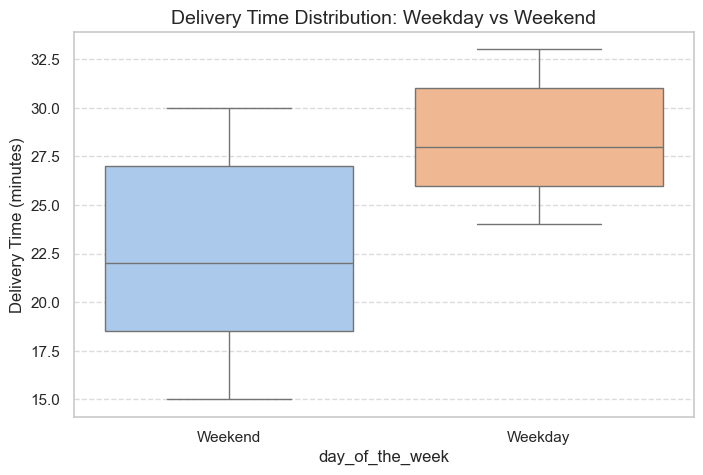

Mean Delivery time in minutes: 
 day_of_the_week
Weekday    28.34
Weekend    22.47
Name: delivery_time, dtype: float64


In [21]:
# Write the code here

#Boxplot to compare delivery times
plt.figure(figsize=(8, 5))
sns.boxplot(x='day_of_the_week', y='delivery_time', data=df, palette='pastel')

plt.title('Delivery Time Distribution: Weekday vs Weekend', fontsize=14)
plt.ylabel('Delivery Time (minutes)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

#Mean delivery time
print("Mean Delivery time in minutes: \n", df.groupby('day_of_the_week')['delivery_time'].mean().round(2))

#### Observations:
As seen, weekend deliveries are generally faster than weekday deliveries and are ~6 minutes faster on average.

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
*  The biggest takeaway (no pun intended) was how consistent the data felt, no matter the variable being addressed. Between ratings, cost, delivery, and day of the week (to name a few that were more frequently used during this investigation), there was solid consistency across all restaurants which shows the value in this service.
* Orders were being ordered quite efficiently and quickly with total time being under an hour and delivery time being just 24 minutes.
* Incentives were provided to loyal and frequently ordering customers.
* Weekend deliveries were faster on average despite the volume of of orders being more.
* Spanish cuisine was ordered explicitly over the weekend.

### Recommendations:

*  As number of ratings are quite low the service should aim to incentivize giving ratings perhaps accruing reward points/credits after each review.
* Have more specials during the week to encourage ordering Spanish cuisine or other underperforming cusines during the week.